In [16]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from sqlalchemy import create_engine, types

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [17]:
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

# Now building the URL with the values from the .env file
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False) 

In [19]:
# Step 1: Load all the CSV files
df_demographic = pd.read_csv('..\data\demographic_data.csv')
df_hypertension_ratios = pd.read_csv('..\data\hypertension_risk_factor_ratios.csv')
df_merged_data = pd.read_csv('..\data\merged_demo_hypertensive_bmi_data.csv')
df_physical_activity = pd.read_csv('..\data\Quest_physical_activity.csv')
df_sleep = pd.read_csv('..\data\Quest_sleep.csv')
df_nutrient = pd.read_csv('..\data\dietary_data\dietary_nutrient_avg_data.csv')

In [6]:
df_demographic.columns

Index(['Participant_ID', 'Interview_Exam_Status', 'Age_Years', 'Gender',
       'Race_Ethnicity', 'Education_Level_Adults', 'Income_Poverty_Ratio',
       'Marital_Status', 'Country_of_Birth', 'Household_Size',
       'Pregnancy_Status', 'Interview_Weight', 'Exam_Weight'],
      dtype='object')

In [20]:
# Rename 'seqn_no' to 'Participant_ID' for consistency in merging keys
df_physical_activity = df_physical_activity.rename(columns={'seqn_no': 'Participant_ID'})
df_sleep = df_sleep.rename(columns={'seqn_no': 'Participant_ID'})
df_hypertension_ratios = df_hypertension_ratios.rename(columns={'seqn_no': 'Participant_ID'})
df_nutrient = df_nutrient .rename(columns={'seqn_no': 'Participant_ID'})


# Select specific columns from each DataFrame
# 1. Ethnicity from demographic_data.csv
df_ethnicity = df_demographic[['Participant_ID', 'Race_Ethnicity','Interview_Weight','Exam_Weight']]

# 2. All columns from merged_demo_hypertensive_bmi_data.csv (already has Participant_ID)
df_main_data = df_merged_data.copy()

# 3. All columns from hypertension_risk_factor_ratios.csv
df_ratios_data = df_hypertension_ratios.copy()

# 4. avg_sleep_hrs from _Quest_sleep.csv
df_sleep_data = df_sleep[['Participant_ID', 'avg_sleep_hrs']]

# 5. Last 4 columns of _Quest_physical_activity.csv
# Assuming the last 4 columns are vig_LTP_count, vig_LTP_unit, vig_LTP_minutes, sed_minutes based on previous info() output
df_physical_activity_selected = df_physical_activity.iloc[:, [0, -4, -3, -2, -1]]
# Verify the column names for physical activity to ensure accuracy
print("Selected physical activity columns and head:")
print(df_physical_activity_selected.head())

# 4. avg_sleep_hrs from _Quest_sleep.csv
df_nutrient = df_nutrient[['Participant_ID', 'nutrient_score']]

# Perform inner joins to combine the selected data
# Start with df_main_data as a base, then join others.
# Inner join ensures only common Participant_IDs across all selected datasets are kept.

merged_df_inner = pd.merge(df_main_data, df_ethnicity, on='Participant_ID', how='inner')
merged_df_inner = pd.merge(merged_df_inner, df_ratios_data, on='Participant_ID', how='inner')
merged_df_inner = pd.merge(merged_df_inner, df_sleep_data, on='Participant_ID', how='inner')
merged_df_inner = pd.merge(merged_df_inner, df_physical_activity_selected, on='Participant_ID', how='inner')
merged_df_inner =  pd.merge(merged_df_inner, df_nutreint, on='Participant_ID', how='inner')

# Display basic information about the final inner-joined DataFrame
print("\nInner Joined DataFrame Head (first 5 rows):")
print(merged_df_inner.head())

print("\nInner Joined DataFrame Information (including non-null counts and data types):")
print(merged_df_inner.info())

print("\nNumber of unique participants in the inner-joined DataFrame:", merged_df_inner['Participant_ID'].nunique())
print("\nTotal number of rows in the inner-joined DataFrame:", len(merged_df_inner))

# Save the inner-joined DataFrame for further EDA steps
merged_df_inner.to_csv('../data/dietary_demo_exam_quest_merged.csv', index=False)

Selected physical activity columns and head:
   Participant_ID  sed_minutes  moderate_activity_minutes_per_week  \
0          130378        360.0                               135.0   
1          130379        480.0                               180.0   
2          130380        240.0                                20.0   
3          130384         60.0                                 0.0   
4          130385        180.0                               630.0   

   vigorous_activity_minutes_per_week activity_level  
0                               135.0         Active  
1                               135.0         Active  
2                                 0.0     Not Active  
3                                 0.0     Not Active  
4                                60.0         Active  

Inner Joined DataFrame Head (first 5 rows):
   Participant_ID  Age  Gender  Hypertensive   BMI  WHR BMI_Category  \
0          130378   43    male          True  27.0  1.0   overweight   
1          1303

 Export to DataBase

In [21]:
# Export to DataBase
merged_df_inner.to_sql(name = 'dietary_demo_exam_quest_merged', con=engine, schema='capstone_group_3',if_exists='replace',index=False)

986

In [22]:
merged_df_inner.columns

Index(['Participant_ID', 'Age', 'Gender', 'Hypertensive', 'BMI', 'WHR',
       'BMI_Category', 'Abdominal_Obesity', 'Race_Ethnicity',
       'Interview_Weight', 'Exam_Weight', 'sodium_to_potassium_ratio',
       'fat_quality_score', 'cholesterol_score', 'energy_intake',
       'vitaminD_IU', 'avg_sleep_hrs', 'sed_minutes',
       'moderate_activity_minutes_per_week',
       'vigorous_activity_minutes_per_week', 'activity_level',
       'nutrient_score'],
      dtype='object')

In [23]:
df = merged_df_inner

In [42]:
import plotly.express as px

# Step 1: Map activity levels to numeric values
activity_mapping = {
    'inactive': 0,
    'low': 1,
    'moderate': 2,
    'active': 3
}

# Step 2: Prepare the filtered DataFrame
hypertensive_df = df[df['Hypertensive'] == 1].copy()
hypertensive_df['activity_level_clean'] = hypertensive_df['activity_level'].str.lower().map(activity_mapping)
hypertensive_df = hypertensive_df.dropna(subset=['activity_level_clean', 'avg_sleep_hrs', 'nutrient_score'])

# Step 3: Create interactive 3D scatter plot
fig = px.scatter_3d(
    hypertensive_df,
    x='avg_sleep_hrs',
    y='nutrient_score',
    z='activity_level_clean',
    color='activity_level',  # Optional: adds color grouping
    opacity=0.6,
    labels={
        'avg_sleep_hrs': 'Avg Sleep Hours',
        'nutrient_score': 'Nutrient Score',
        'activity_level_clean': 'Activity Level'
    },
    title='Hypertensive Adults: Sleep vs Nutrition vs Activity Level'
)



fig.show()

fig.write_html('3d_scatter_plot.html')

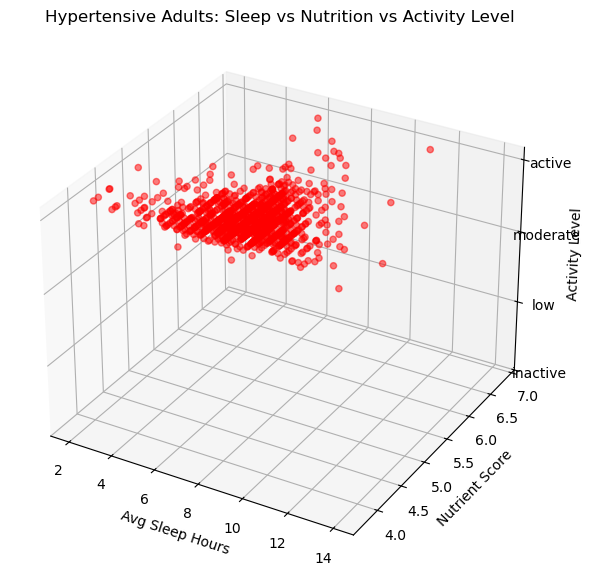

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Step 1: Create a numeric mapping that matches lowercase values exactly
activity_mapping = {
    'inactive': 0,
    'low': 1,
    'moderate': 2,
    'active': 3
}

# Step 2: Filter hypertensive individuals
hypertensive_df = df[df['Hypertensive'] == 1].copy()

# Step 3: Map activity levels to numeric values
hypertensive_df['activity_numeric'] = hypertensive_df['activity_level'].str.lower().map(activity_mapping)

# Step 4: Drop rows with missing or unmapped values
hypertensive_df = hypertensive_df.dropna(subset=['activity_numeric', 'avg_sleep_hrs', 'nutrient_score'])

# Step 5: Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    hypertensive_df['avg_sleep_hrs'],
    hypertensive_df['nutrient_score'],
    hypertensive_df['activity_numeric'],
    c='red', alpha=0.5
)

ax.set_xlabel('Avg Sleep Hours')
ax.set_ylabel('Nutrient Score')
ax.set_zlabel('Activity Level')
ax.set_title('Hypertensive Adults: Sleep vs Nutrition vs Activity Level')

# Optional: show actual activity labels on the Z-axis
ax.set_zticks(list(activity_mapping.values()))
ax.set_zticklabels(list(activity_mapping.keys()))



plt.tight_layout()
plt.show()


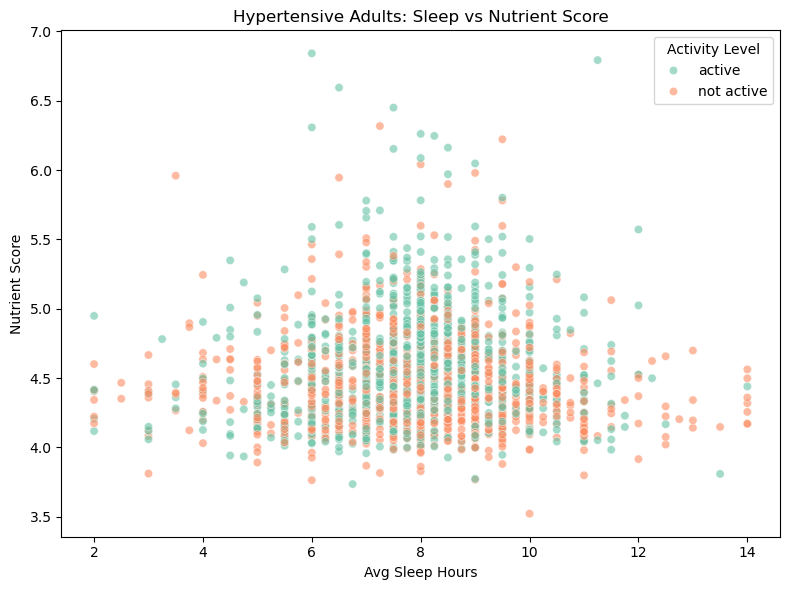

In [28]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=hypertensive_df,
    x='avg_sleep_hrs',
    y='nutrient_score',
    hue='activity_level',
    alpha=0.6,
    palette='Set2'
)
plt.title("Hypertensive Adults: Sleep vs Nutrient Score")
plt.xlabel("Avg Sleep Hours")
plt.ylabel("Nutrient Score")
plt.legend(title="Activity Level")
plt.tight_layout()
plt.show()

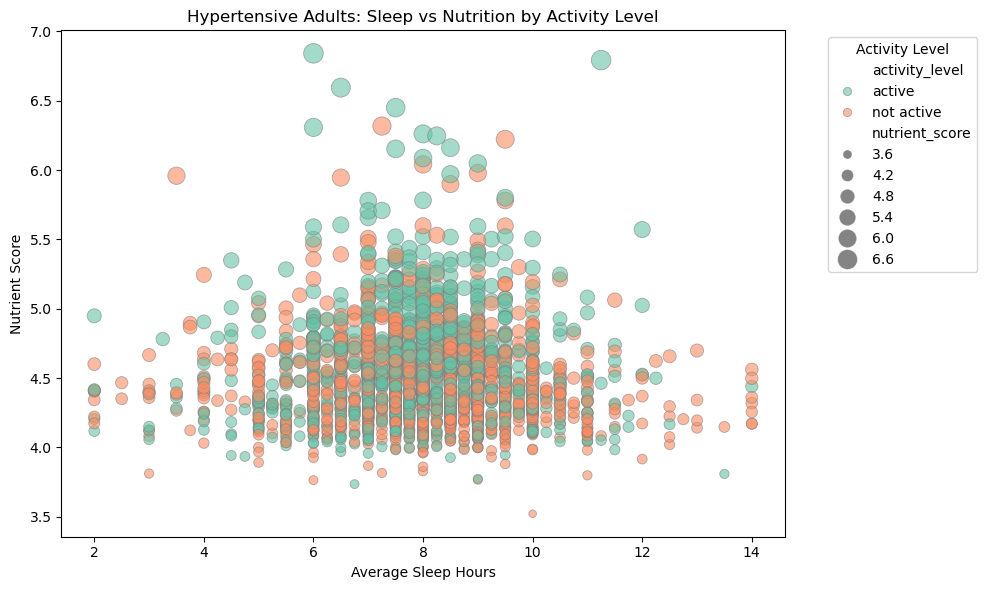

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for hypertensive individuals
hypertensive_df = df[df['Hypertensive'] == 1].copy()

# Ensure 'activity_level' is treated as a category
if hypertensive_df['activity_level'].dtype != 'category':
    hypertensive_df['activity_level'] = hypertensive_df['activity_level'].astype('category')

# 2D scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=hypertensive_df,
    x='avg_sleep_hrs',
    y='nutrient_score',
    hue='activity_level',
    size='nutrient_score',
    sizes=(30, 200),
    alpha=0.6,
    palette='Set2',
    edgecolor='gray'
)

plt.xlabel("Average Sleep Hours")
plt.ylabel("Nutrient Score")
plt.title("Hypertensive Adults: Sleep vs Nutrition by Activity Level")
plt.legend(title="Activity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

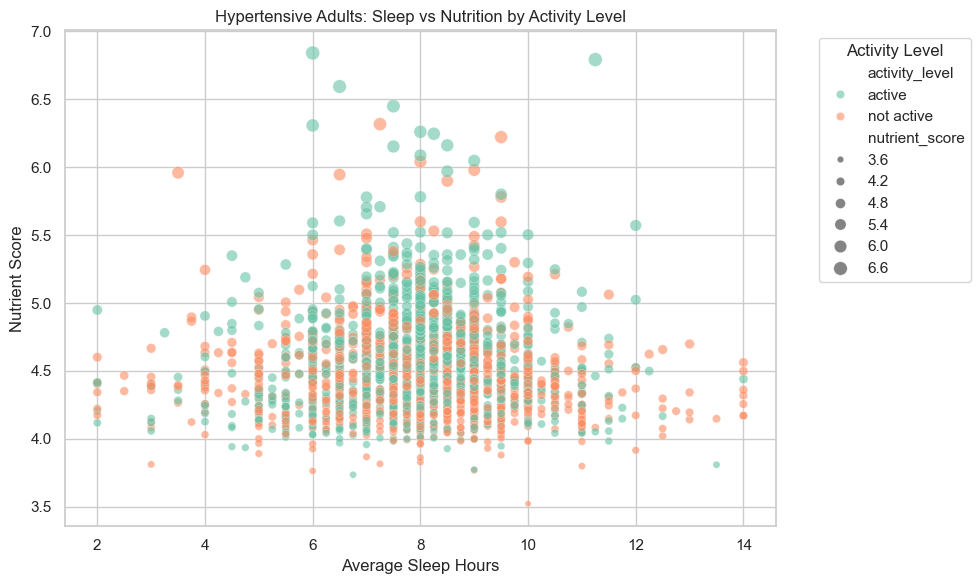

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=hypertensive_df,
    x='avg_sleep_hrs',
    y='nutrient_score',
    hue='activity_level',
    size='nutrient_score',
    sizes=(20, 100),
    alpha=0.6,
    palette='Set2',
    edgecolor='white',
    linewidth=0.3
)

plt.xlabel("Average Sleep Hours")
plt.ylabel("Nutrient Score")
plt.title("Hypertensive Adults: Sleep vs Nutrition by Activity Level")
plt.legend(title="Activity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

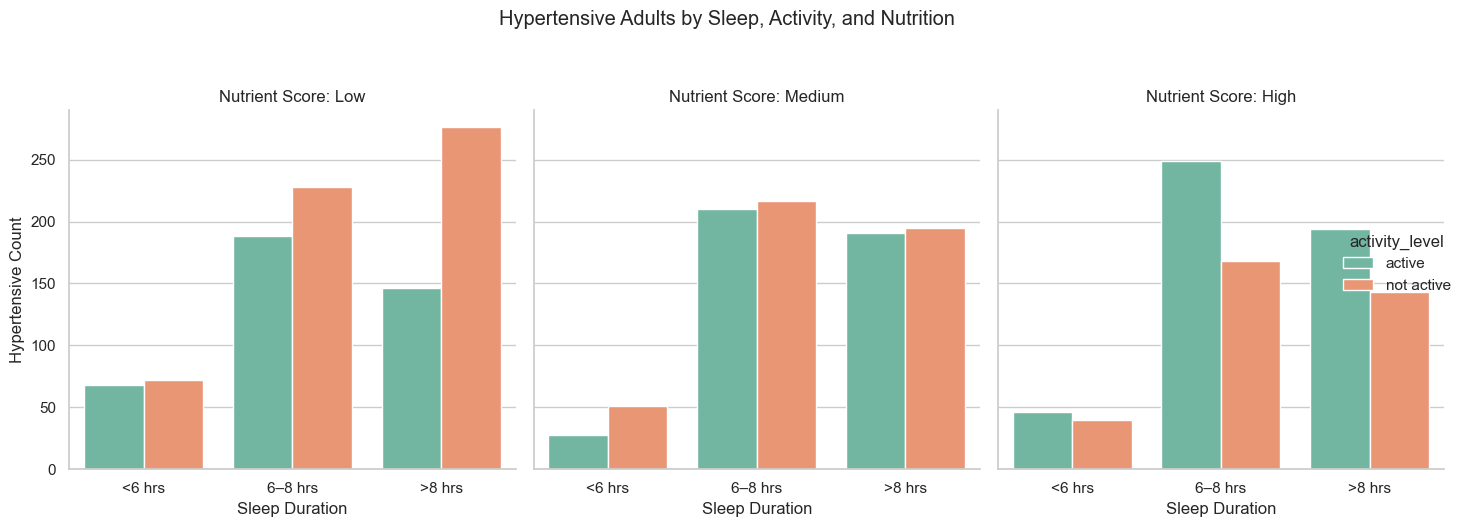

In [33]:
# Sleep bins
df['sleep_bin'] = pd.cut(df['avg_sleep_hrs'], bins=[0, 6, 8, 24], labels=['<6 hrs', '6–8 hrs', '>8 hrs'])

# Nutrient score bins (tertiles)
df['nutrient_bin'] = pd.qcut(df['nutrient_score'], q=3, labels=['Low', 'Medium', 'High'])

# Ensure activity level is categorical
df['activity_level'] = df['activity_level'].astype('category')


# Only hypertensive
hyper = df[df['Hypertensive'] == 1]

grouped = hyper.groupby(['sleep_bin', 'activity_level', 'nutrient_bin']).size().reset_index(name='count')

sns.set(style='whitegrid')

g = sns.catplot(
    data=grouped,
    x='sleep_bin',
    y='count',
    hue='activity_level',
    col='nutrient_bin',
    kind='bar',
    palette='Set2',
    height=5,
    aspect=0.9
)

g.set_axis_labels("Sleep Duration", "Hypertensive Count")
g.set_titles("Nutrient Score: {col_name}")
g.fig.suptitle("Hypertensive Adults by Sleep, Activity, and Nutrition", y=1.05)
plt.tight_layout()
plt.show()

In [27]:
# Filter hypertensive individuals
hypertensive_df = df[df['Hypertensive'] == 1]

# Check distribution
print(hypertensive_df['nutrient_score'].describe())

count    2724.000000
mean        4.498675
std         0.340708
min         3.522063
25%         4.273648
50%         4.437525
75%         4.660654
max         6.841680
Name: nutrient_score, dtype: float64


In [ ]:
# STEP 1: Copy original dataframe
df = merged_df_inner.copy()

# STEP 2: Create binary threat indicators
diet_thresh = 1.0  # <-- adjust as per your definition
sed_thresh = 480   # 8 hours in minutes

df['is_pro_hypertensive_diet'] = (df['sodium_to_potassium_ratio'] > diet_thresh).astype(int)
df['is_excessive_sedentary'] = (df['sed_minutes'] > sed_thresh).astype(int)
df['is_disordered_sleep'] = ((df['avg_sleep_hrs'] < 6) | (df['avg_sleep_hrs'] > 9)).astype(int)


In [36]:
# Step 1: Create the DataFrame
threat_df = pd.DataFrame({
    'Risk Factor': [
        'Sleep Disorder',
        'nutrient score',
        'Activity level'
    ],
    'Hypertension Prevalence (%)': [58.6, 55.0, 54.8]
})

# Step 2: Sort for visual clarity
threat_df = threat_df.sort_values(by='Hypertension Prevalence (%)', ascending=False)

# Step 3: Define color scale (darker = higher prevalence)
colors = px.colors.sequential.Blues
color_scale = threat_df['Hypertension Prevalence (%)'].rank().astype(int)

# Step 4: Create Plotly bar chart
fig = px.bar(
    threat_df,
    x='Risk Factor',
    y='Hypertension Prevalence (%)',
    color='Hypertension Prevalence (%)',
    color_continuous_scale='Blues',
    text=threat_df['Hypertension Prevalence (%)'].apply(lambda x: f"{x:.1f}%"),
    title='Hypertension Prevalence by Lifestyle Risk Factor',
)

# Step 5: Customize layout
fig.update_traces(
    textposition='outside',
    marker=dict(line=dict(color='black', width=0.8))
)
fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    xaxis_title='Lifestyle Risk Factor',
    yaxis_title='Hypertension Prevalence (%)',
    yaxis_range=[0, 70],
    plot_bgcolor='white',
    coloraxis_showscale=False
)

# Step 6: Show figure
fig.show()